In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.simplefilter("ignore", UserWarning)


In [ ]:
import kagglehub


path = kagglehub.dataset_download("madhuraatmarambhagat/crop-recommendation-dataset")

print("Path to dataset files:", path)

100%|██████████| 63.7k/63.7k [00:00<00:00, 19.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/madhuraatmarambhagat/crop-recommendation-dataset/versions/1


## About Dataset

🌾 **Context**

This dataset is structured to predict the most suitable crop for cultivation based on various agroclimatic parameters. It is typically used in precision agriculture and machine learning applications, aiming to support farmers, agricultural consultants, and policymakers.

---

### **Features (Inputs):**

- **N** – Nitrogen content in the soil (in mg/kg)
- **P** – Phosphorus content in the soil (in mg/kg)
- **K** – Potassium content in the soil (in mg/kg)
- **temperature** – Average temperature in °C
- **humidity** – Average relative humidity in %
- **ph** – Soil pH value
- **rainfall** – Rainfall in mm

---

### **Label (Output):**

- **label** – The crop most suited to the given conditions (e.g., rice, maize, cotton, etc.)


source : [link](https://www.kaggle.com/datasets/madhuraatmarambhagat/crop-recommendation-dataset)


# Classification

## Exploratory Analysis


In [ ]:
dataset = pd.read_csv(path +"/Crop_recommendation.csv")
dataset.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print(dataset.isna().sum())
print(dataset.isnull().sum())
dataset.describe()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## SVM - CLF

In [ ]:
y = dataset.loc[:, "label"].values
y.shape

(2200,)

In [ ]:
y_head = pd.DataFrame(y)
y_head.head()

,0
0,rice
1,rice
2,rice
3,rice
4,rice


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
lbc = LabelEncoder()
y_label_encoder = lbc.fit_transform(dataset["label"])
y_label_encoder

array([20, 20, 20, ...,  5,  5,  5])

In [ ]:
print(lbc.classes_)

mapeamento = dict(zip(range(len(lbc.classes_)), lbc.classes_))
print(mapeamento)


['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
{0: 'apple', 1: 'banana', 2: 'blackgram', 3: 'chickpea', 4: 'coconut', 5: 'coffee', 6: 'cotton', 7: 'grapes', 8: 'jute', 9: 'kidneybeans', 10: 'lentil', 11: 'maize', 12: 'mango', 13: 'mothbeans', 14: 'mungbean', 15: 'muskmelon', 16: 'orange', 17: 'papaya', 18: 'pigeonpeas', 19: 'pomegranate', 20: 'rice', 21: 'watermelon'}


In [ ]:
X = dataset.loc[:, ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X_treino, X_teste, y_treino_LABEL_ENCODER, y_teste_LABEL_ENCODER = train_test_split(
    X, y_label_encoder, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

In [ ]:
svm_agro = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

In [ ]:
svm_agro.fit(X_treino_scaled, y_treino_LABEL_ENCODER)


SVC(random_state=42)

## Manual Testing

In [ ]:
idx = 15

amostra = X_teste_scaled[idx].reshape(1, -1)
label_verdadeiro = y_teste_LABEL_ENCODER[idx]
label_predito = svm_agro.predict(amostra)[0]

nome_verdadeiro = lbc.inverse_transform([label_verdadeiro])[0]
nome_predito = lbc.inverse_transform([label_predito])[0]


print(f"Índice: {idx}")
print(f"Label verdadeiro: {nome_verdadeiro} ({label_verdadeiro})")
print(f"Label predito: {nome_predito} ({label_predito})")
print(f"Correto: {label_verdadeiro == label_predito}")

Índice: 15
Label verdadeiro: pomegranate (19)
Label predito: pomegranate (19)
Correto: True


In [ ]:
score_teste = svm_agro.score(X_teste_scaled, y_teste_LABEL_ENCODER)
print(f"Acurácia no teste: {score_teste:.4f}")

Acurácia no teste: 0.9655


In [ ]:
score_treino = svm_agro.score(X_treino_scaled, y_treino_LABEL_ENCODER)
print(f"Acurácia no treino: {score_treino:.4f}")

Acurácia no treino: 0.9885


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

predicoes = svm_agro.predict(X_teste_scaled)

print(f"Acurácia: {accuracy_score(y_teste_LABEL_ENCODER, predicoes):.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_teste_LABEL_ENCODER, predicoes,
                          target_names=lbc.classes_))

Acurácia: 0.9655

Relatório de classificação:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        29
      banana       1.00      1.00      1.00        23
   blackgram       0.92      0.96      0.94        24
    chickpea       1.00      1.00      1.00        31
     coconut       1.00      1.00      1.00        27
      coffee       0.96      1.00      0.98        26
      cotton       0.91      1.00      0.95        21
      grapes       1.00      1.00      1.00        19
        jute       0.74      0.96      0.84        27
 kidneybeans       0.92      1.00      0.96        24
      lentil       0.83      1.00      0.91        15
       maize       1.00      0.91      0.95        23
       mango       1.00      1.00      1.00        27
   mothbeans       1.00      0.92      0.96        26
    mungbean       1.00      1.00      1.00        26
   muskmelon       1.00      1.00      1.00        22
      orange       1.00      1.00  

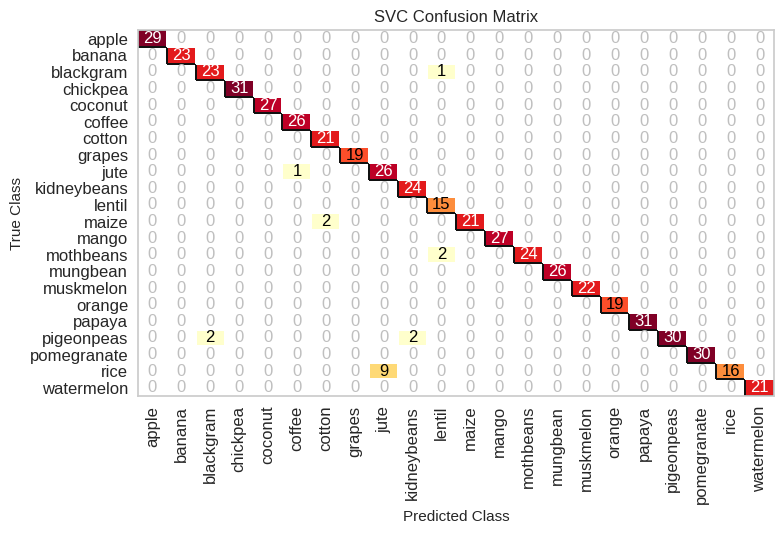

<Axes: title={'center': 'SVC Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(svm_agro, classes=lbc.classes_)
cm.fit(X_treino_scaled, y_treino_LABEL_ENCODER)
cm.score(X_teste_scaled, y_teste_LABEL_ENCODER)
cm.show()